# 🔍 Rossmann Retail Sales Forecasting
## Notebook 1: Data Exploration & Analysis

**Author:** Cephas Adams Kumah  
**Dataset:** Rossmann Store Sales (Kaggle)  
**Records:** 1,017,209 raw records across 1,115 stores from 2013 to 2015  
**Objective:** Understand sales patterns, identify key business drivers, and inform feature engineering decisions for the forecasting model.

---

### Notebook Workflow

| Step | Description |
|---|---|
| **1. Setup** | Load required libraries and configure chart styling |
| **2. Load Data** | Import the training and store datasets and inspect their structure |
| **3. Data Quality Review** | Check data types, missing values, and the date range |
| **4. Clean & Merge Data** | Filter closed days, handle missing values, and merge sales records with store attributes |
| **5. Sales by Day of Week** | Analyse which days generate the highest average sales |
| **6. Monthly Sales Trends** | Identify seasonal sales patterns across years |
| **7. Sales by Store Type** | Compare sales performance across different store formats |
| **8. Promotion Impact** | Quantify how active promotions affect average daily sales |

## 1. Setup

Standard data science libraries are loaded for data manipulation, numerical analysis, and visualisation. Global matplotlib settings are configured to apply a consistent clean style across all charts, including white backgrounds, minimal spines, subtle gridlines, and readable font sizes.

This setup ensures that all exploratory visualisations are consistent, clear, and suitable for reporting or portfolio presentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "sans serif",
    "axes.titlesize":     13,
    "axes.labelsize":     11,
})

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Data

The Rossmann dataset consists of two source files:

| File | Records | Description |
|---|---:|---|
| `train.csv` | 1,017,209 | Daily store-level sales records, including dates, promotions, and holiday indicators |
| `store.csv` | 1,115 | Store-level attributes, including store type, competition distance, assortment, and promotion details |

Both files are loaded and reviewed for dataset shape, column names, and data types before cleaning or transformation begins.

In [2]:
train = pd.read_csv('../data/train.csv', low_memory=False)
store = pd.read_csv('../data/store.csv')

print(f"Train shape: {train.shape}")
print(f"Store shape: {store.shape}")
print(f"\nTrain columns: {train.columns.tolist()}")
print(f"\nStore columns: {store.columns.tolist()}")

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Store columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [3]:
#Preview train data
train.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [4]:
#Preview store data
store.head(10)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


## 3. Data Quality Check

Both datasets are inspected for missing values, data types, and potential inconsistencies before analysis. This step helps identify cleaning decisions required before merging and feature engineering.

Key findings:

- `CompetitionDistance` contains missing values and is later filled with the median distance.
- `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`, `Promo2SinceWeek`, and `Promo2SinceYear` contain missing values for stores without recorded competition or Promo2 history and are filled with `0`.
- `PromoInterval` is missing for stores not participating in Promo2 and is filled with `"None"`.
- `StateHoliday` contains mixed representations of non-holiday values and is converted to string format before encoding.

In [5]:
print("TRAIN DATA INFO:")
print(train.dtypes)
print(f"\nMissinfg values in train")
print(train.isnull().sum()[train.isnull().sum() >0])

print("STORE DATA INFO:")
print(store.dtypes)
print(f"\nMissing values in store")
print(store.isnull().sum()[store.isnull().sum() >0])

TRAIN DATA INFO:
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

Missinfg values in train
Series([], dtype: int64)
STORE DATA INFO:
Store                          int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

Missing values in store
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


## 4. Clean & Merge

The `Date` column is converted from string format to `datetime` format to support time-based analysis, trend exploration, and chronological feature creation.

### Filtering Decisions

- Rows where `Open = 0` are removed because they represent closed store days and do not provide useful sales demand signals.
- Rows where `Sales = 0` are removed because they represent non-trading or anomalous records that would distort average sales patterns.

After filtering, the dataset is limited to **open trading days only**, which provides a more appropriate scope for analysing sales behaviour and preparing the forecasting dataset.

The cleaned sales data is then merged with store-level attributes using the `Store` column, allowing each daily sales record to include information such as store type, assortment, competition distance, and promotion history.

In [6]:
#Convert Date column
train["Date"] = pd.to_datetime(train["Date"])
print(f"Date range: {train['Date'].min()} to {train['Date'].max()}")
print(f"Total days: {train['Date'].nunique()}")

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Total days: 942


In [7]:
#Remove closed store days
# Stores with Sales=0 and Open=0 are closed — remove them
print(f"Rows before removing closed days : {len(train)}")
train = train[train['Open'] == 1]
train = train[train['Sales'] > 0]
print(f"Rows after removing closed days: {len(train)}")
print(f"Zero sales removed: this leaves only trading days")

Rows before removing closed days : 1017209
Rows after removing closed days: 844338
Zero sales removed: this leaves only trading days


In [8]:
#Fix store missing values
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median, inplace=True)
store['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
store['CompetitionOpenSinceYear'].fillna(0, inplace=True)
store['Promo2SinceWeek'].fillna(0, inplace=True)
store['Promo2SinceYear'].fillna(0, inplace=True)
store['PromoInterval'].fillna('None', inplace=True)

print(f"Missing Values after fixing")
print(store.isnull().sum()[store.isnull().sum() > 0])
print("All Fixed!" if store.isnull().sum().sum() == 0 else "Still some missing")

Missing Values after fixing
Series([], dtype: int64)
All Fixed!


In [9]:
# Merge train and store
df = train.merge(store, on='Store', how='left')
print(f"Merged dataset shpe: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Merged dataset shpe: (844338, 18)
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [10]:
#Basic sales statistics
print("Sales statistics")
print(df['Sales'].describe())
print(f"\nAverage daily sales: €{df['Sales'].mean():,.0f}")
print(f"Max daily sales: €{df['Sales'].max():,.0f}")
print(f"Min daily sales: €{df['Sales'].min():,.0f}")

Sales statistics
count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

Average daily sales: €6,956
Max daily sales: €41,551
Min daily sales: €46


## 5. Sales by Day of Week

Average sales are calculated for each day of the week to identify recurring weekly trading patterns. This analysis highlights the days that consistently generate the highest and lowest sales, providing insight into customer purchasing behaviour and store demand.

The results also validate the inclusion of the **`DayOfWeek`** feature in the forecasting model, as weekly seasonality is an important driver of retail sales.

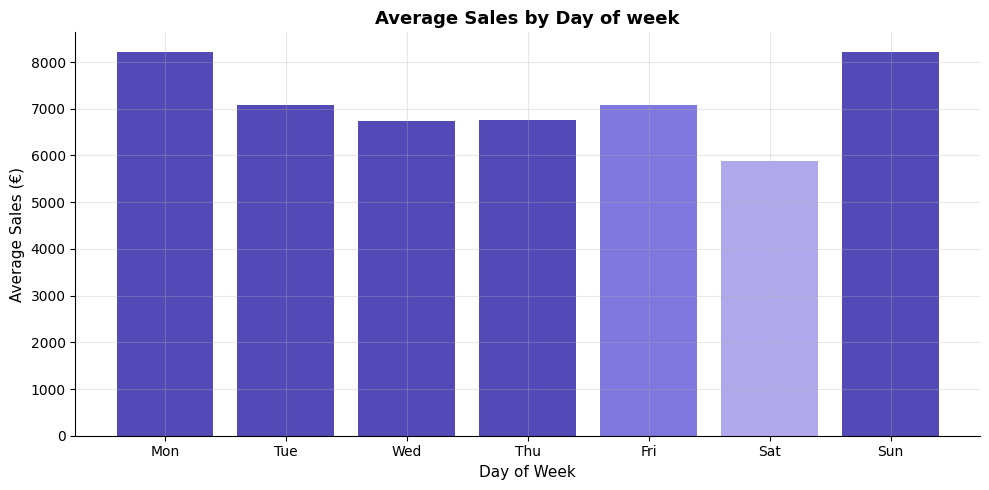

Chhart saved


In [12]:
# Map numeric day values to readable day names
day_names = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
# Calculate average sales for each day of the week
daily_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
# Create a new column with the actual day names
daily_sales['Day'] = daily_sales['DayOfWeek'].map(day_names)

# Set the chart size
plt.figure(figsize=(10,5))
# Create a bar chart showing average sales by day
plt.bar(daily_sales['Day'], daily_sales['Sales'],
        color=['#534AB7','#534AB7','#534AB7','#534AB7','#7F77DD','#AFA9EC','#534AB7' ])
plt.title('Average Sales by Day of week', fontweight='bold') 
plt.ylabel('Average Sales (€)')
plt.xlabel('Day of Week')
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.savefig('../visuals/sales_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chhart saved")

## 6. Sales by Month & Year

Monthly average sales are plotted across the available years from 2013 to 2015 to examine seasonal sales patterns. Each year is shown as a separate line, making it easier to compare whether demand peaks and dips occur consistently across years.

This analysis helps validate the use of calendar-based features such as **`Month`**, **`Quarter`**, and **`WeekOfYear`** in the forecasting model.

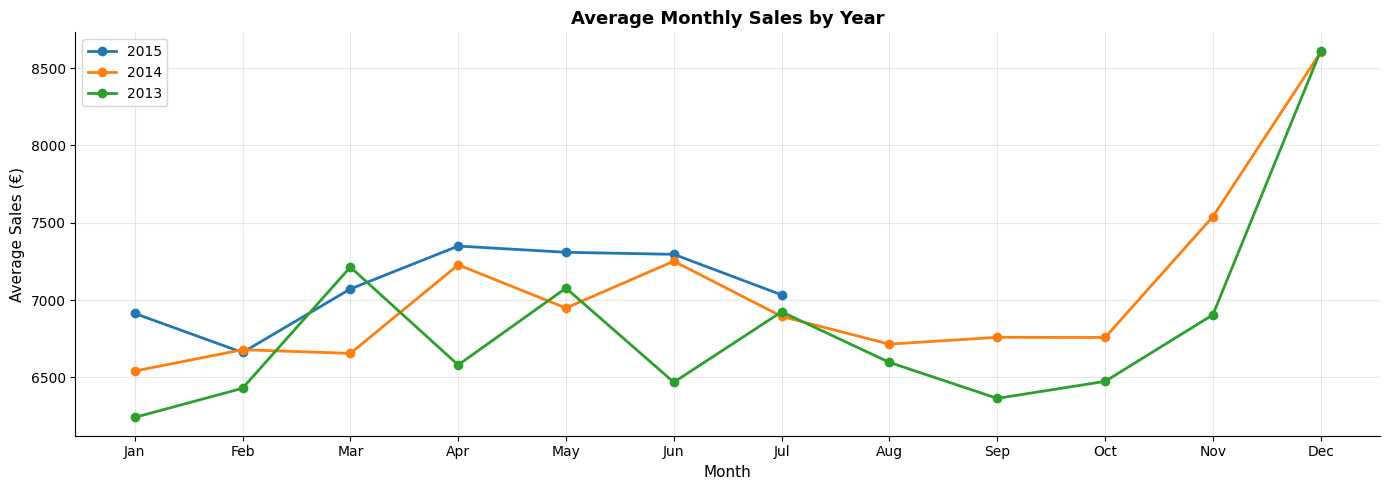

Chart saved.


In [13]:
# Extract month and year from the Date column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
# Calculate average sales for each month in each year
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
# Set chart size
plt.figure(figsize=(14,5))
# Plot one line for each year
for year in df['Year'].unique():
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(
        data['Month'],
        data['Sales'],
        marker='o',
        linewidth=2,
        label=str(year)
    )
 # Add chart title and axis labels
plt.title('Average Monthly Sales by Year', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales (€)')
# Replace month numbers with month names
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. Sales by Store Type

Average sales are compared across the four Rossmann store formats: A, B, C, and D. These store types may differ in size, location, assortment strategy, and customer base, which can lead to meaningful differences in revenue performance.

This analysis helps validate the use of **`StoreType_enc`** as a modelling feature and provides business context for the store performance insights presented in the Power BI dashboard.

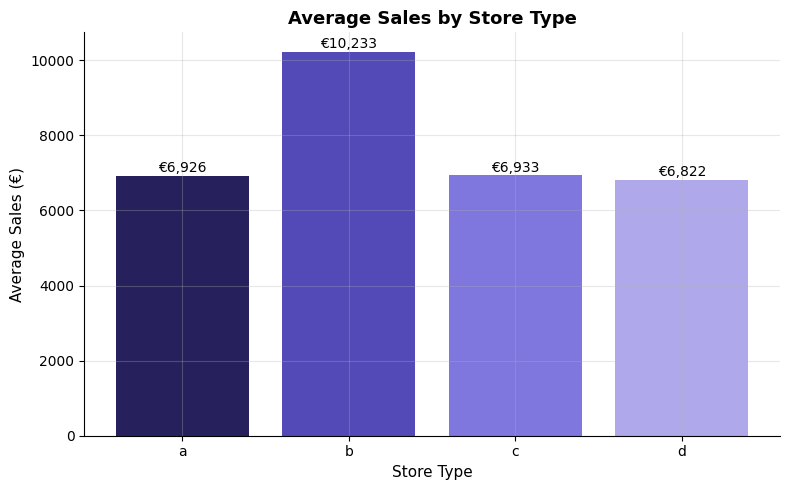

Chart saved.


In [14]:
# Calculate the average sales for each store type
store_type_sales = df.groupby('StoreType')['Sales'].mean().reset_index()

# Set the chart size
plt.figure(figsize=(8,5))
# Create a bar chart of average sales by store type
plt.bar(
    store_type_sales['StoreType'],
    store_type_sales['Sales'],
    color=['#26215C','#534AB7','#7F77DD','#AFA9EC']
)
# Add title and axis labels
plt.title('Average Sales by Store Type', fontweight='bold')
plt.ylabel('Average Sales (€)')
plt.xlabel('Store Type')

# Add value labels above each bar
for i, val in enumerate(store_type_sales['Sales']):
    plt.text(
        i,
        val + 100,
         f'€{val:,.0f}', 
        ha='center', 
        fontsize=10
    )

plt.tight_layout()
plt.savefig('../visuals/sales_by_store_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


## 8. Promo Impact on Sales

Average daily sales are compared between promotion and non-promotion days to measure the revenue impact of promotional activity. This analysis helps quantify whether promotions are associated with higher sales performance.

The results support the inclusion of **`Promo`** as a key modelling feature and confirm that promotional activity is one of the strongest business-controlled drivers of sales in the dataset.

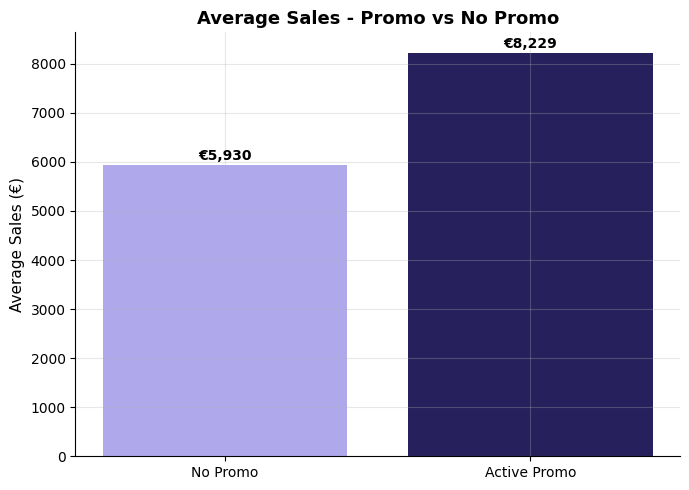

Chart saved.


In [15]:
# Calculate average sales for promo and non-promo days
promo_sales = df.groupby('Promo')['Sales'].mean().reset_index()
# Rename promo values for clearer chart labels
promo_sales['label'] = promo_sales['Promo'].map({
     0: 'No Promo', 
    1: 'Active Promo'
})
# Set chart size
plt.figure(figsize=(7,5))
#create bar chart
bars = plt.bar(
    promo_sales['label'],
    promo_sales['Sales'],
    color=['#AFA9EC', '#26215C']
)
plt.title('Average Sales - Promo vs No Promo', fontweight='bold')
plt.ylabel('Average Sales (€)')
# Add value labels above bars
for bar, val in zip(bars, promo_sales['Sales']):
    plt.text(bar.get_x() + bar.get_width() /2,
             bar.get_height() + 100,
             f'€{val:,.0f}',
             ha='center',
             fontweight='bold'
    )
plt.tight_layout()
plt.savefig('../visuals/promo_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## ✅ Exploratory Analysis Complete

The exploratory analysis identified several business patterns that guided feature engineering and model development.

| Finding | Modelling Implication |
|---|---|
| Monday records the highest average sales | Include `DayOfWeek` to capture weekly trading patterns |
| Sales exhibit clear seasonal variation across months | Include calendar features such as `Month`, `Quarter`, and `WeekOfYear` |
| Store performance varies by store type | Include `StoreType` as a predictive feature |
| Promotion days generate substantially higher sales | Include `Promo` as a key business feature |
| Competition and store characteristics influence sales performance | Merge store-level attributes into the modelling dataset |

> **Next:** Open **`02_feature_engineering.ipynb`** to create lag features, rolling statistics, calendar features, and encoded categorical variables for model training.